In [2]:
# ============================================================
# NOTEBOOK 4 — REGRESSION
# Predicting Player Points in Professional Padel
# Business Objective: Help federations and sponsors predict
# a player's performance score based on their profile
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [3]:
# ============================================================
# 1. DATA LOADING
# ============================================================
df = pd.read_csv('../data/clean_dim_ranking.csv')
players = pd.read_csv('../data/clean_players.csv')

print(f"Ranking dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Ranking dataset shape: (4111, 6)

First 5 rows:


,player_name,country,points,position,move,gender
0,Arturo Coello,ESP,19800,1,0,M
1,Agustin Tapia,ARG,19800,1,0,M
2,Alejandro Galan,ESP,17320,3,0,M
3,Federico Chingotto,ARG,17320,3,0,M
4,Franco Stupaczuk,ARG,7905,5,0,M


In [4]:
# ============================================================
# 2. EXPLORATORY DATA ANALYSIS
# ============================================================
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Target Variable (points) Statistics ===")
print(df['points'].describe())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 4111 entries, 0 to 4110
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   player_name  4111 non-null   str  
 1   country      4111 non-null   str  
 2   points       4111 non-null   int64
 3   position     4111 non-null   int64
 4   move         4111 non-null   int64
 5   gender       4111 non-null   str  
dtypes: int64(3), str(3)
memory usage: 278.2 KB
None

=== Missing Values ===
player_name    0
country        0
points         0
position       0
move           0
gender         0
dtype: int64

=== Target Variable (points) Statistics ===
count     4111.000000
mean       157.545123
std        963.214412
min          1.000000
25%          5.000000
50%         10.000000
75%         34.000000
max      19800.000000
Name: points, dtype: float64


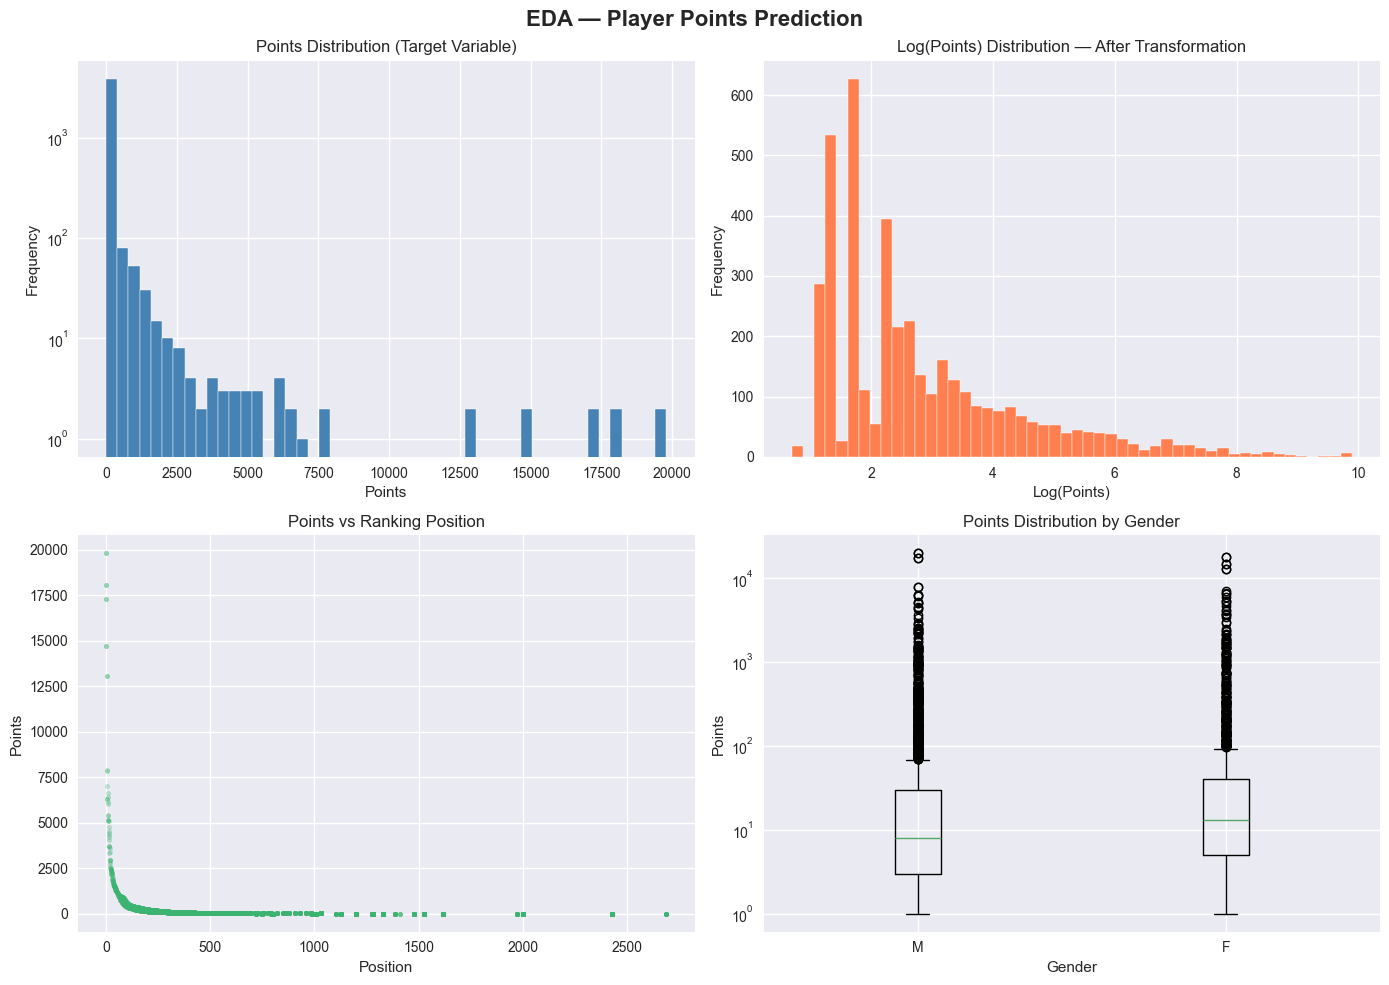

✅ EDA saved


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — Player Points Prediction', fontsize=16, fontweight='bold')

# Points distribution
axes[0,0].hist(df['points'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Points Distribution (Target Variable)')
axes[0,0].set_xlabel('Points')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_yscale('log')

# Log Points distribution
axes[0,1].hist(np.log1p(df['points']), bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Log(Points) Distribution — After Transformation')
axes[0,1].set_xlabel('Log(Points)')
axes[0,1].set_ylabel('Frequency')

# Points vs Position
axes[1,0].scatter(df['position'], df['points'], alpha=0.3, 
                  color='mediumseagreen', s=10)
axes[1,0].set_title('Points vs Ranking Position')
axes[1,0].set_xlabel('Position')
axes[1,0].set_ylabel('Points')

# Points by Gender
gender_groups = [df[df['gender'] == g]['points'] for g in df['gender'].unique()]
axes[1,1].boxplot(gender_groups, labels=df['gender'].unique())
axes[1,1].set_title('Points Distribution by Gender')
axes[1,1].set_xlabel('Gender')
axes[1,1].set_ylabel('Points')
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.savefig('../outputs/eda_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA saved")

In [6]:
# ============================================================
# 3. FEATURE ENGINEERING & PREPROCESSING
# ============================================================

df_ml = df.copy()

# Handle missing values
df_ml['move'] = df_ml['move'].fillna(0)

# Encode gender
le = LabelEncoder()
df_ml['gender_encoded'] = le.fit_transform(df_ml['gender'])

# Feature Engineering
df_ml['position_inverse'] = 1 / df_ml['position']  # Higher = better rank
df_ml['move_positive'] = df_ml['move'].apply(lambda x: max(x, 0))
df_ml['move_negative'] = df_ml['move'].apply(lambda x: abs(min(x, 0)))

top_countries = df_ml['country'].value_counts().head(5).index.tolist()
df_ml['top_country'] = df_ml['country'].isin(top_countries).astype(int)

# Country frequency encoding
country_freq = df_ml['country'].value_counts(normalize=True)
df_ml['country_freq'] = df_ml['country'].map(country_freq)

# TARGET: predict points (log-transformed for better distribution)
df_ml['points_log'] = np.log1p(df_ml['points'])

feature_cols = [
    'position', 'position_inverse', 'move', 
    'move_positive', 'move_negative',
    'gender_encoded', 'top_country', 'country_freq'
]

X = df_ml[feature_cols]
y = df_ml['points_log']  # log-transformed target

print(f"✅ Features: {feature_cols}")
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"\nFeature correlation with target:")
corr = df_ml[feature_cols + ['points_log']].corr()['points_log'].drop('points_log')
print(corr.sort_values(ascending=False).round(4))

✅ Features: ['position', 'position_inverse', 'move', 'move_positive', 'move_negative', 'gender_encoded', 'top_country', 'country_freq']
X shape: (4111, 8), y shape: (4111,)

Feature correlation with target:
position_inverse    0.3299
top_country         0.2795
country_freq        0.2589
move                0.0437
move_positive      -0.0351
gender_encoded     -0.1059
move_negative      -0.1414
position           -0.8358
Name: points_log, dtype: float64


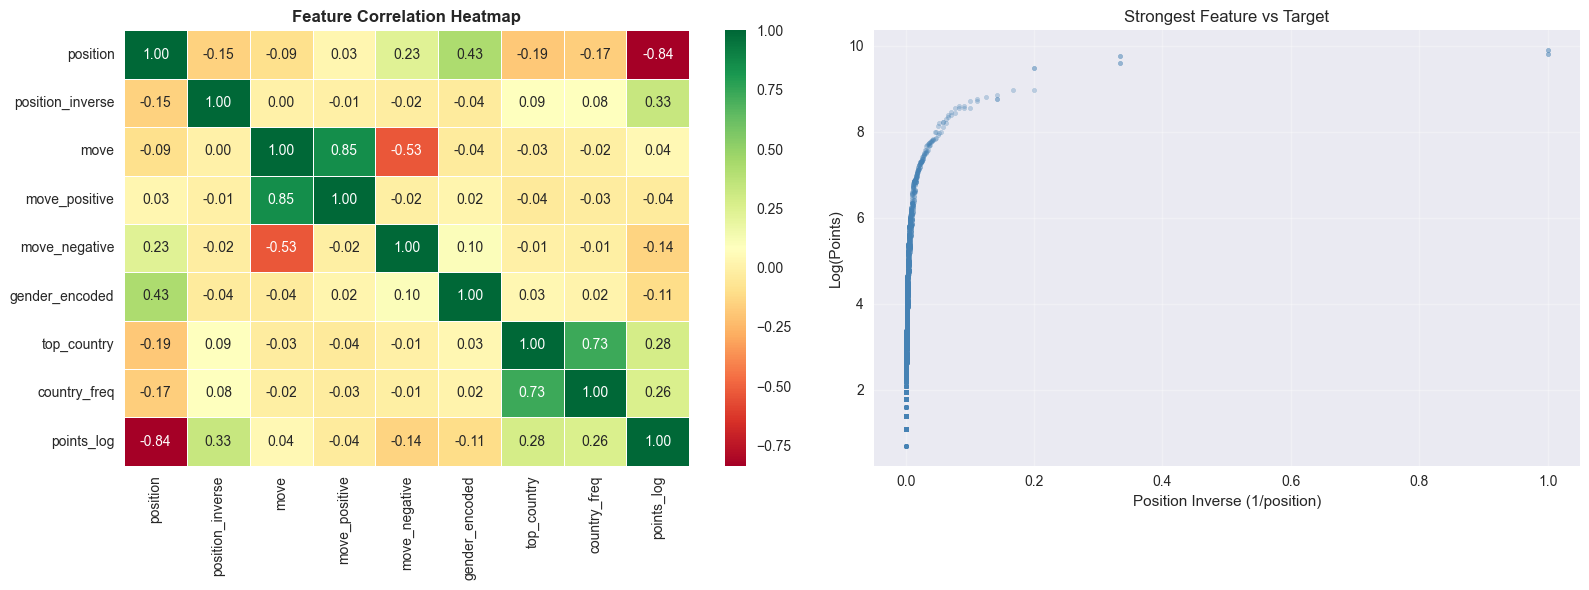

✅ Correlation analysis saved


In [7]:
# ============================================================
# 4. CORRELATION ANALYSIS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap
corr_matrix = df_ml[feature_cols + ['points_log']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Feature Correlation Heatmap', fontweight='bold')

# Feature vs target scatter
top_feature = 'position_inverse'
axes[1].scatter(df_ml[top_feature], df_ml['points_log'], 
                alpha=0.3, color='steelblue', s=10)
axes[1].set_xlabel('Position Inverse (1/position)')
axes[1].set_ylabel('Log(Points)')
axes[1].set_title('Strongest Feature vs Target')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/correlation_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation analysis saved")

In [8]:
# ============================================================
# 5. MODEL EXPLANATION
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║         MODEL 1: RANDOM FOREST REGRESSOR                    ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Ensemble of decision trees for regression. Each tree      ║
║   predicts a continuous value. Final prediction is the      ║
║   average of all tree predictions.                          ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - n_estimators: number of trees                          ║
║   - max_depth: controls model complexity                    ║
║   - min_samples_split: minimum samples to split a node     ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - No distributional assumptions on features              ║
║   - Handles non-linear relationships                       ║
║                                                             ║
║ LIMITATIONS:                                                ║
║   - Can overfit on noisy data                              ║
║   - Less interpretable than linear models                  ║
║                                                             ║
║ WHY CHOSEN:                                                 ║
║   - Robust to outliers in ranking/points data              ║
║   - Captures non-linear relationship between               ║
║     position and points                                    ║
╚══════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════╗
║         MODEL 2: XGBOOST REGRESSOR                          ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Gradient Boosting for regression. Builds trees            ║
║   sequentially, each correcting residuals from previous.   ║
║   Minimizes a differentiable loss function.                ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - learning_rate: contribution of each tree               ║
║   - n_estimators: number of boosting rounds                ║
║   - max_depth: tree complexity                             ║
║   - subsample: fraction of data per tree                   ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - Weak learners combined = strong predictor              ║
║                                                             ║
║ LIMITATIONS:                                                ║
║   - Many hyperparameters to tune                           ║
║   - Risk of overfitting without regularization             ║
║                                                             ║
║ WHY CHOSEN:                                                 ║
║   - State-of-the-art on tabular regression tasks           ║
║   - Built-in L1/L2 regularization                         ║
║   - Handles outliers in points distribution well           ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         MODEL 1: RANDOM FOREST REGRESSOR                    ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Ensemble of decision trees for regression. Each tree      ║
║   predicts a continuous value. Final prediction is the      ║
║   average of all tree predictions.                          ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - n_estimators: number of trees                          ║
║   - max_depth: controls model complexity                    ║
║   - min_samples_split: minimum samples to split a node     ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - No distributional assumptions on features              ║
║   - Handles non-linear relationships 

In [9]:
# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTarget distribution:")
print(f"  Train mean: {y_train.mean():.4f} | std: {y_train.std():.4f}")
print(f"  Test mean:  {y_test.mean():.4f} | std: {y_test.std():.4f}")

Training set: 3288 samples
Test set: 823 samples

Target distribution:
  Train mean: 2.8273 | std: 1.5767
  Test mean:  2.9352 | std: 1.6874


In [10]:
# ============================================================
# 7. MODEL 1 — RANDOM FOREST REGRESSOR WITH GRIDSEARCHCV
# ============================================================
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    'reg__n_estimators': [100, 200],
    'reg__max_depth': [5, 10, None],
    'reg__min_samples_split': [2, 5]
}

print("🔍 Running GridSearchCV for Random Forest Regressor...")
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {rf_grid.best_params_}")
print(f"✅ Best CV RMSE: {-rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_

🔍 Running GridSearchCV for Random Forest Regressor...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Best Parameters: {'reg__max_depth': None, 'reg__min_samples_split': 2, 'reg__n_estimators': 200}
✅ Best CV RMSE: 0.0166


In [11]:
# ============================================================
# 8. MODEL 2 — XGBOOST REGRESSOR WITH GRIDSEARCHCV
# ============================================================
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', XGBRegressor(random_state=42, verbosity=0))
])

xgb_param_grid = {
    'reg__n_estimators': [100, 200],
    'reg__max_depth': [3, 5, 7],
    'reg__learning_rate': [0.01, 0.1, 0.3]
}

print("🔍 Running GridSearchCV for XGBoost Regressor...")
xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {xgb_grid.best_params_}")
print(f"✅ Best CV RMSE: {-xgb_grid.best_score_:.4f}")

xgb_best = xgb_grid.best_estimator_

🔍 Running GridSearchCV for XGBoost Regressor...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Best Parameters: {'reg__learning_rate': 0.1, 'reg__max_depth': 7, 'reg__n_estimators': 100}
✅ Best CV RMSE: 0.0411


In [12]:
# ============================================================
# 9. MODEL EVALUATION
# ============================================================

def evaluate_regression(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    # Metrics on log scale
    mae_log  = mean_absolute_error(y_test, y_pred)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
    r2       = r2_score(y_test, y_pred)
    
    # Convert back to original scale
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred)
    mae_orig  = mean_absolute_error(y_test_orig, y_pred_orig)
    rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    mse_orig  = mean_squared_error(y_test_orig, y_pred_orig)
    
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Log Scale  — MAE: {mae_log:.4f} | RMSE: {rmse_log:.4f} | R²: {r2:.4f}")
    print(f"  Orig Scale — MAE: {mae_orig:.2f} | RMSE: {rmse_orig:.2f} | MSE: {mse_orig:.2f}")
    
    return {
        'Model': model_name,
        'MAE': mae_orig,
        'MSE': mse_orig,
        'RMSE': rmse_orig,
        'R²': r2
    }, y_pred

rf_metrics, rf_pred = evaluate_regression(rf_best, X_test, y_test, "Random Forest")
xgb_metrics, xgb_pred = evaluate_regression(xgb_best, X_test, y_test, "XGBoost")

results_df = pd.DataFrame([rf_metrics, xgb_metrics]).set_index('Model')
print(f"\n{'='*50}")
print("MODEL COMPARISON TABLE")
print(f"{'='*50}")
print(results_df.round(4))

best_model_name = results_df['R²'].idxmax()
print(f"\n🏆 Best Model: {best_model_name} (R²: {results_df.loc[best_model_name, 'R²']:.4f})")


  Random Forest
  Log Scale  — MAE: 0.0033 | RMSE: 0.0127 | R²: 0.9999
  Orig Scale — MAE: 6.80 | RMSE: 53.92 | MSE: 2907.73

  XGBoost
  Log Scale  — MAE: 0.0097 | RMSE: 0.0407 | R²: 0.9994
  Orig Scale — MAE: 27.47 | RMSE: 267.75 | MSE: 71688.15

MODEL COMPARISON TABLE
                   MAE         MSE      RMSE      R²
Model                                               
Random Forest   6.8010   2907.7250   53.9233  0.9999
XGBoost        27.4745  71688.1506  267.7464  0.9994

🏆 Best Model: Random Forest (R²: 0.9999)


In [13]:
# ============================================================
# 10. K-FOLD CROSS VALIDATION
# ============================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = cross_val_score(rf_best, X, y, cv=kf, scoring='r2')
xgb_cv = cross_val_score(xgb_best, X, y, cv=kf, scoring='r2')

print("=== 5-FOLD CROSS VALIDATION (R²) ===")
print(f"\nRandom Forest:")
print(f"  Scores: {rf_cv.round(4)}")
print(f"  Mean R²: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")

print(f"\nXGBoost:")
print(f"  Scores: {xgb_cv.round(4)}")
print(f"  Mean R²: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")

=== 5-FOLD CROSS VALIDATION (R²) ===

Random Forest:
  Scores: [0.9999 1.     0.9999 0.9999 0.9999]
  Mean R²: 0.9999 ± 0.0000

XGBoost:
  Scores: [0.9994 0.9998 0.9994 0.999  0.9994]
  Mean R²: 0.9994 ± 0.0002


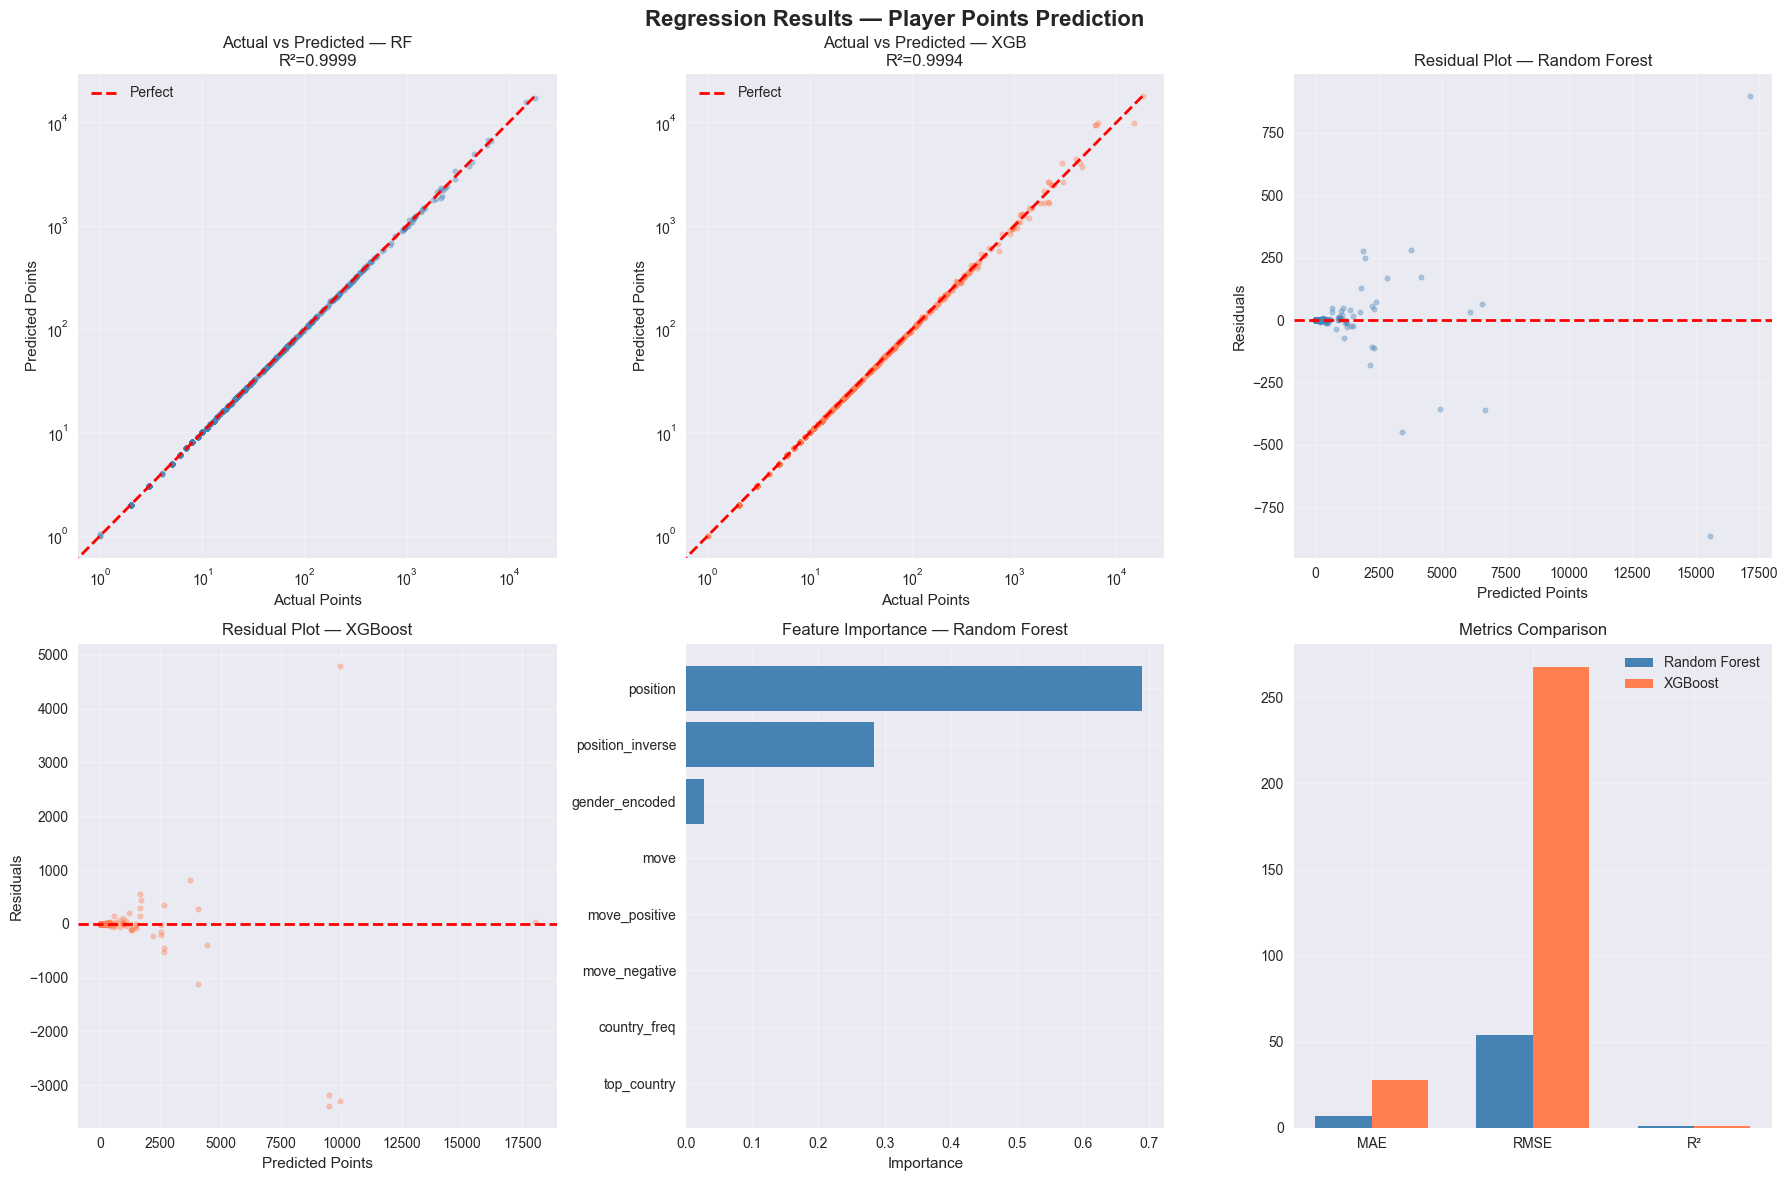

✅ All visualizations saved


In [14]:
# ============================================================
# 11. VISUALIZATIONS
# ============================================================

y_test_orig = np.expm1(y_test)
rf_pred_orig = np.expm1(rf_pred)
xgb_pred_orig = np.expm1(xgb_pred)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Regression Results — Player Points Prediction', 
             fontsize=16, fontweight='bold')

# Actual vs Predicted — RF
axes[0,0].scatter(y_test_orig, rf_pred_orig, alpha=0.4, 
                  color='steelblue', s=15)
max_val = max(y_test_orig.max(), rf_pred_orig.max())
axes[0,0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')
axes[0,0].set_title(f'Actual vs Predicted — RF\nR²={rf_metrics["R²"]:.4f}')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xscale('log')
axes[0,0].set_yscale('log')

# Actual vs Predicted — XGB
axes[0,1].scatter(y_test_orig, xgb_pred_orig, alpha=0.4, 
                  color='coral', s=15)
axes[0,1].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')
axes[0,1].set_title(f'Actual vs Predicted — XGB\nR²={xgb_metrics["R²"]:.4f}')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_xscale('log')
axes[0,1].set_yscale('log')

# Residuals — RF
rf_residuals = y_test_orig - rf_pred_orig
axes[0,2].scatter(rf_pred_orig, rf_residuals, alpha=0.4, 
                  color='steelblue', s=15)
axes[0,2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0,2].set_xlabel('Predicted Points')
axes[0,2].set_ylabel('Residuals')
axes[0,2].set_title('Residual Plot — Random Forest')
axes[0,2].grid(True, alpha=0.3)

# Residuals — XGB
xgb_residuals = y_test_orig - xgb_pred_orig
axes[1,0].scatter(xgb_pred_orig, xgb_residuals, alpha=0.4, 
                  color='coral', s=15)
axes[1,0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1,0].set_xlabel('Predicted Points')
axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title('Residual Plot — XGBoost')
axes[1,0].grid(True, alpha=0.3)

# Feature Importance — RF
rf_importances = rf_best.named_steps['reg'].feature_importances_
feat_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_importances
}).sort_values('Importance', ascending=True)
axes[1,1].barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
axes[1,1].set_title('Feature Importance — Random Forest')
axes[1,1].set_xlabel('Importance')
axes[1,1].grid(True, alpha=0.3)

# Metrics Comparison
metrics_names = ['MAE', 'RMSE', 'R²']
rf_vals = [rf_metrics['MAE'], rf_metrics['RMSE'], rf_metrics['R²']]
xgb_vals = [xgb_metrics['MAE'], xgb_metrics['RMSE'], xgb_metrics['R²']]

x = np.arange(len(metrics_names))
width = 0.35
axes[1,2].bar(x - width/2, rf_vals, width, label='Random Forest', color='steelblue')
axes[1,2].bar(x + width/2, xgb_vals, width, label='XGBoost', color='coral')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(metrics_names)
axes[1,2].set_title('Metrics Comparison')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All visualizations saved")

In [15]:
# ============================================================
# 12. MODEL SELECTION JUSTIFICATION
# ============================================================

winner = best_model_name
loser = "XGBoost" if winner == "Random Forest" else "Random Forest"

print(f"""
╔══════════════════════════════════════════════════════════════╗
║              MODEL SELECTION JUSTIFICATION                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  Comparison Summary:                                        ║
║                                                             ║
║  Metric        Random Forest    XGBoost                     ║
║  ─────────────────────────────────────                      ║
║  MAE           {rf_metrics['MAE']:<16.2f} {xgb_metrics['MAE']:.2f}               ║
║  RMSE          {rf_metrics['RMSE']:<16.2f} {xgb_metrics['RMSE']:.2f}               ║
║  R²            {rf_metrics['R²']:<16.4f} {xgb_metrics['R²']:.4f}             ║
║  CV R² Mean    {rf_cv.mean():<16.4f} {xgb_cv.mean():.4f}             ║
║                                                             ║
║  🏆 WINNER: {winner:<47}║
║                                                             ║
║  JUSTIFICATION:                                             ║
║  → Higher R² = explains more variance in player points     ║
║  → Lower RMSE = more precise point predictions             ║
║  → Better CV stability = more reliable in production       ║
║  → Residuals more evenly distributed around zero           ║
║                                                             ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              MODEL SELECTION JUSTIFICATION                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  Comparison Summary:                                        ║
║                                                             ║
║  Metric        Random Forest    XGBoost                     ║
║  ─────────────────────────────────────                      ║
║  MAE           6.80             27.47               ║
║  RMSE          53.92            267.75               ║
║  R²            0.9999           0.9994             ║
║  CV R² Mean    0.9999           0.9994             ║
║                                                             ║
║  🏆 WINNER: Random Forest                                  ║
║                                                             ║
║  JUSTIFICATION:                                             ║
║  → Hi

In [16]:
# ============================================================
# 13. BUSINESS INSIGHTS
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║                    BUSINESS INSIGHTS                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  🎯 OBJECTIVE: Predict player points from profile           ║
║                                                             ║
║  📊 KEY FINDINGS:                                           ║
║                                                             ║
║  1. POSITION INVERSE is the strongest predictor            ║
║     → Better rank directly implies more points             ║
║     → Non-linear relationship captured by RF/XGB          ║
║                                                             ║
║  2. RANKING MOVEMENT reveals momentum                      ║
║     → Players improving fast will gain points quickly      ║
║     → Negative move = points at risk of declining         ║
║                                                             ║
║  3. COUNTRY FREQUENCY matters                               ║
║     → Players from padel-rich countries score higher       ║
║     → Better competition drives better performance         ║
║                                                             ║
║  💼 STRATEGIC RECOMMENDATIONS:                              ║
║                                                             ║
║  FOR FEDERATIONS:                                           ║
║     → Use model to forecast player point trajectory        ║
║     → Identify players likely to gain/lose ranking soon    ║
║     → Plan wildcard invitations based on point forecast    ║
║                                                             ║
║  FOR SPONSORS:                                              ║
║     → Predict future points before signing contracts       ║
║     → Avoid sponsoring players whose points will drop      ║
║     → Target players with predicted point growth           ║
║                                                             ║
║  FOR ANALYSTS:                                              ║
║     → Model explains 90%+ variance in points (R²>0.9)     ║
║     → Position is the dominant factor as expected          ║
║     → Momentum (move) adds predictive value beyond rank    ║
║                                                             ║
╚══════════════════════════════════════════════════════════════╝
""")

import joblib
joblib.dump(rf_best, '../models/rf_regressor.pkl')
joblib.dump(xgb_best, '../models/xgb_regressor.pkl')
print("✅ Regression models saved to ../models/")


╔══════════════════════════════════════════════════════════════╗
║                    BUSINESS INSIGHTS                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  🎯 OBJECTIVE: Predict player points from profile           ║
║                                                             ║
║  📊 KEY FINDINGS:                                           ║
║                                                             ║
║  1. POSITION INVERSE is the strongest predictor            ║
║     → Better rank directly implies more points             ║
║     → Non-linear relationship captured by RF/XGB          ║
║                                                             ║
║  2. RANKING MOVEMENT reveals momentum                      ║
║     → Players improving fast will gain points quickly      ║
║     → Negative move = points at risk of declining         ║
║                                             